# Fransa Milli Takımı - Dünya Kupası 2022 Serüveni Analizi

Bu notebook, Fransa'nın 2022 Dünya Kupası boyunca oynadığı **tüm maçları** analiz eder ve karşılaştırır. 
Tek bir maç yerine, takımın turnuva boyunca pas ağının nasıl değiştiğini, hangi oyuncuların hangi maçlarda daha merkezi olduğunu inceler.

In [45]:
from statsbombpy import sb
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch

pd.set_option('display.max_columns', None)
%matplotlib inline

## 1. Veri Hazırlığı: Fransa'nın Tüm Maçlarını Bulma
Önce Dünya Kupası 2022 ID'lerini alıyoruz, ardından Fransa'nın dahil olduğu tüm maçları tarihe göre sıralıyoruz.

In [13]:
takim="France"
rakip="Argentina"
year=2022

# 1. Turnuva ID'lerini Bul
comps = sb.competitions()
wc_2022 = comps[(comps['competition_name'] == 'FIFA World Cup') & (comps['season_name'] == '2022')]
competition_id = wc_2022.iloc[0]['competition_id']
season_id = wc_2022.iloc[0]['season_id']

# 2. Maçları Çek
matches = sb.matches(competition_id=competition_id, season_id=season_id)

# 3. Fransa Maçlarını Filtrele
france_matches = matches[
    (matches['home_team'] == takim) | 
    (matches['away_team'] == takim)
].copy()

# Tarihe göre sırala (Grup maçlarından finale doğru)
france_matches['match_date'] = pd.to_datetime(france_matches['match_date'])
france_matches = france_matches.sort_values(by='match_date')

print(f"{takim}ın Oynadığı Toplam Maç Sayısı: {len(france_matches)}")
display(france_matches[['match_date', 'match_week', 'home_team', 'away_team', 'home_score', 'away_score', 'competition_stage']])

Argentinaın Oynadığı Toplam Maç Sayısı: 7


C:\Users\erdal\AppData\Roaming\Python\Python312\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_date,match_week,home_team,away_team,home_score,away_score,competition_stage
37,2022-11-22,1,Argentina,Saudi Arabia,1,2,Group Stage
13,2022-11-26,2,Argentina,Mexico,2,0,Group Stage
11,2022-11-30,3,Poland,Argentina,0,2,Group Stage
1,2022-12-03,4,Argentina,Australia,2,1,Round of 16
6,2022-12-09,5,Netherlands,Argentina,2,2,Quarter-finals
19,2022-12-13,6,Argentina,Croatia,3,0,Semi-finals
9,2022-12-18,7,Argentina,France,3,3,Final


## 2. Analiz Fonksiyonu
Her maç için ayrı ayrı kod yazmak yerine, bir maçı alıp bize o maçın ağ istatistiklerini (Yoğunluk, En Merkezi Oyuncu vb.) döndüren bir fonksiyon yazıyoruz.

In [15]:
def analyze_match_network(match_row):
    match_id = match_row['match_id']
    
    # Rakip takımı bul (Grafikte etiket için)
    opponent = match_row['away_team'] if match_row['home_team'] == 'France' else match_row['home_team']
    stage = match_row['competition_stage']
    
    # Olayları çek
    events = sb.events(match_id=match_id)
    
    # Sadece Fransa ve Paslar
    france_passes = events[
        (events['team'] == takim) & 
        (events['type'] == 'Pass') & 
        (events['pass_outcome'].isna()) # Başarılı paslar
    ].copy()
    
    # Veri Temizliği
    france_passes = france_passes.dropna(subset=['player', 'pass_recipient'])
    
    # Edge List Oluştur
    pass_counts = france_passes.groupby(['player', 'pass_recipient']).size().reset_index(name='pass_count')
    
    # Graf İnşası
    G = nx.DiGraph()
    for _, row in pass_counts.iterrows():
        G.add_edge(row['player'], row['pass_recipient'], weight=row['pass_count'])
        
    # --- METRİKLER ---
    
    # 1. Başarılı Pas Sayısı
    total_passes = len(france_passes)
    
    # 2. Ağ Yoğunluğu (Network Density): Oyuncular ne kadar birbirine bağlı?
    # Değer 0-1 arasındadır. 1'e yakınsa herkes herkese pas atıyor demektir.
    density = nx.density(G)
    
    # 3. Betweenness Centrality Lideri (Oyunun Merkezi)
    if len(G) > 0:
        betweenness = nx.betweenness_centrality(G, weight='weight')
        top_player = max(betweenness, key=betweenness.get)
        top_player_score = betweenness[top_player]
    else:
        top_player = "N/A"
        top_player_score = 0
        
    return {
        'Match Date': match_row['match_date'],
        'Opponent': opponent,
        'Stage': stage,
        'Total Successful Passes': total_passes,
        'Network Density': density,
        'Key Playmaker': top_player,
        'Playmaker Score': top_player_score
    }

## Örnek (Final Maçı)

In [31]:
print("Fetching World Cup 2022 match data...")

# Find World Cup 2022
comps = sb.competitions()
wc_2022 = comps[(comps['competition_name'] == 'FIFA World Cup') & (comps['season_name'] == '2022')]

if wc_2022.empty:
    print("Could not find World Cup 2022 data.")
else:
    competition_id = wc_2022.iloc[0]['competition_id']
    season_id = wc_2022.iloc[0]['season_id']
    print(f"Found World Cup 2022: ID {competition_id}, Season {season_id}")

    # Find the match: Argentina vs France
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    
    final_match = matches[
        ((matches['home_team'] == 'France') | (matches['away_team'] == 'France')) &
        ((matches['home_team'] == 'Argentina') | (matches['away_team'] == 'Argentina'))
    ]
    
    if final_match.empty:
        print("Could not find the France vs Argentina match.")
    else:
        match_id = final_match.iloc[0]['match_id']
        home_team = final_match.iloc[0]['home_team']
        away_team = final_match.iloc[0]['away_team']
        print(f"Analyzing Match: {home_team} vs {away_team} (ID: {match_id})")

Fetching World Cup 2022 match data...


C:\Users\erdal\AppData\Roaming\Python\Python312\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Found World Cup 2022: ID 43, Season 106
Analyzing Match: Argentina vs France (ID: 3869685)


In [33]:
print("Fetching match events (this may take a moment)...")
events = sb.events(match_id=match_id)

Fetching match events (this may take a moment)...


C:\Users\erdal\AppData\Roaming\Python\Python312\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [35]:
# Filter for team France
france_events = events[events['team'] == 'France'].copy()

# Filter for passes
if 'type' in france_events.columns:
    passes = france_events[france_events['type'] == 'Pass']
else:
    print("No 'type' column found.")

# Filter for successful passes
# For success, 'pass_outcome' is usually NaN
if 'pass_outcome' in passes.columns:
    successful_passes = passes[passes['pass_outcome'].isna()]
else:
    print("Warning: 'pass_outcome' column not found, using all passes.")
    successful_passes = passes

print(f"Total Successful Passes by France: {len(successful_passes)}")

Total Successful Passes by France: 434


In [37]:
# Drop rows where recipient is missing
successful_passes = successful_passes.dropna(subset=['player', 'pass_recipient'])

# Build Edge list with counts (weight)
pass_counts = successful_passes.groupby(['player', 'pass_recipient']).size().reset_index(name='pass_count')

# Calculate average positions
successful_passes[['x', 'y']] = pd.DataFrame(successful_passes['location'].tolist(), index=successful_passes.index)
average_locs = successful_passes.groupby('player')[['x', 'y']].mean()

In [39]:
G = nx.DiGraph()

# Add edges
for _, row in pass_counts.iterrows():
    G.add_edge(row['player'], row['pass_recipient'], weight=row['pass_count'])

# Calculate Centrality Metrics
degree = nx.degree_centrality(G)
in_degree = nx.in_degree_centrality(G)
out_degree = nx.out_degree_centrality(G)
betweenness = nx.betweenness_centrality(G, weight='weight')

# Organize metrics into a DataFrame
metrics_df = pd.DataFrame({
    'Player': list(G.nodes()),
    'Degree': [degree.get(n, 0) for n in G.nodes()],
    'In-Degree': [in_degree.get(n, 0) for n in G.nodes()],
    'Out-Degree': [out_degree.get(n, 0) for n in G.nodes()],
    'Betweenness': [betweenness.get(n, 0) for n in G.nodes()]
}).sort_values(by='Betweenness', ascending=False)

print("--- Top Players by Betweenness Centrality ---")
display(metrics_df.head(5))

print("\n--- Top Players by Total Degree ---")
display(metrics_df.sort_values(by='Degree', ascending=False).head(5))

--- Top Players by Betweenness Centrality ---


,Player,Degree,In-Degree,Out-Degree,Betweenness
5,Jules Koundé,1.6250,0.8750,0.7500,0.156376
7,Kylian Mbappé Lottin,1.1875,0.6250,0.5625,0.115099
10,Randal Kolo Muani,1.0000,0.6250,0.3750,0.101940
11,Raphaël Varane,1.4375,0.6875,0.7500,0.100095
8,Marcus Thuram,1.1875,0.5625,0.6250,0.097440



--- Top Players by Total Degree ---


,Player,Degree,In-Degree,Out-Degree,Betweenness
5,Jules Koundé,1.6250,0.8750,0.7500,0.156376
0,Adrien Rabiot,1.6250,0.8750,0.7500,0.075224
2,Aurélien Djani Tchouaméni,1.5625,0.7500,0.8125,0.088016
11,Raphaël Varane,1.4375,0.6875,0.7500,0.100095
3,Dayotchanculle Upamecano,1.3750,0.6250,0.7500,0.068046


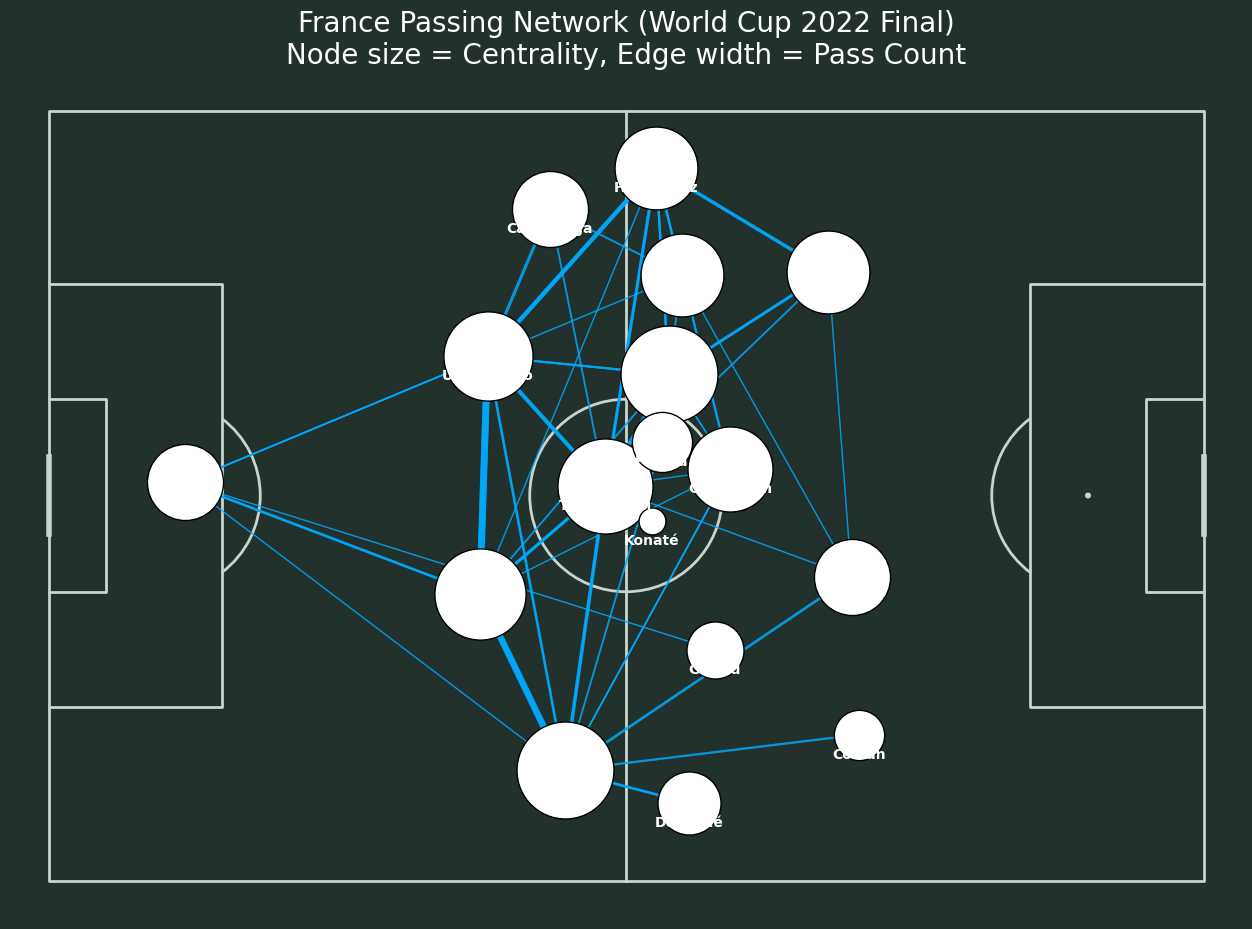

In [47]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)
fig.set_facecolor('#22312b')

MAX_NODE_SIZE = 600
MIN_PASS_COUNT = 3
MAX_LINE_WIDTH = 5

# Draw Nodes
for player in G.nodes():
    if player in average_locs.index:
        x, y = average_locs.loc[player]
        size = degree[player] * MAX_NODE_SIZE * 5
        
        pitch.scatter(x, y, ax=ax, s=size, color='white', edgecolors='black', zorder=10)
        
        name_label = player.split(' ')[-1]
        pitch.annotate(name_label, (x, y+2), ax=ax, color='white', ha='center', va='center', fontsize=10, zorder=11, fontweight='bold')

# Draw Edges
for u, v, d in G.edges(data=True):
    count = d['weight']
    if count >= MIN_PASS_COUNT:
        if u in average_locs.index and v in average_locs.index:
            x1, y1 = average_locs.loc[u]
            x2, y2 = average_locs.loc[v]
            
            width = (count / pass_counts['pass_count'].max()) * MAX_LINE_WIDTH
            pitch.lines(x1, y1, x2, y2, ax=ax, lw=width, color='#00aaff', alpha=0.6, zorder=5, transparent=True)

plt.title('France Passing Network (World Cup 2022 Final)\nNode size = Centrality, Edge width = Pass Count', color='white', fontsize=20)
plt.show()

## 3. Döngüsel Analiz
Şimdi tüm maçlar üzerinde dönerek verileri topluyoruz. (Veri çekme işlemi internet hızına göre 1-2 dakika sürebilir)

In [49]:
results = []

print("Analiz başlıyor // Her maç için veriler çekiliyor...")

for index, row in france_matches.iterrows():
    print(f"İşleniyor: vs {row['away_team'] if row['home_team'] == 'France' else row['home_team']} ({row['competition_stage']})")
    try:
        metrics = analyze_match_network(row)
        results.append(metrics)
    except Exception as e:
        print(f"Hata oluştu ({row['match_id']}): {e}")

results_df = pd.DataFrame(results)
print("\n--- Analiz Tamamlandı ---")
display(results_df)

Analiz başlıyor // Her maç için veriler çekiliyor...
İşleniyor: vs Argentina (Group Stage)
İşleniyor: vs Argentina (Group Stage)
İşleniyor: vs Poland (Group Stage)
İşleniyor: vs Argentina (Round of 16)
İşleniyor: vs Netherlands (Quarter-finals)
İşleniyor: vs Argentina (Semi-finals)
İşleniyor: vs Argentina (Final)

--- Analiz Tamamlandı ---


,Match Date,Opponent,Stage,Total Successful Passes,Network Density,Key Playmaker,Playmaker Score
0,2022-11-22,Argentina,Group Stage,542,0.590476,Nicolás Alejandro Tagliafico,0.202930
1,2022-11-26,Argentina,Group Stage,476,0.520833,Enzo Fernandez,0.229444
2,2022-11-30,Poland,Group Stage,826,0.641667,Nahuel Molina Lucero,0.252698
3,2022-12-03,Argentina,Round of 16,646,0.554167,Lautaro Javier Martínez,0.205839
4,2022-12-09,Netherlands,Quarter-finals,531,0.540441,Alexis Mac Allister,0.195833
5,2022-12-13,Argentina,Semi-finals,358,0.504167,Cristian Gabriel Romero,0.174286
6,2022-12-18,Argentina,Final,560,0.474265,Marcos Javier Acuña,0.268785


## 4. Karşılaştırmalı Görselleştirme

### A. Maç Başına Pas Sayısı ve Ağ Yoğunluğu
Takımın hangi maçlarda daha fazla paslaştığını (Pas Hacmi) ve hangi maçlarda daha kompleks bir ağ kurduğunu (Yoğunluk) görelim.

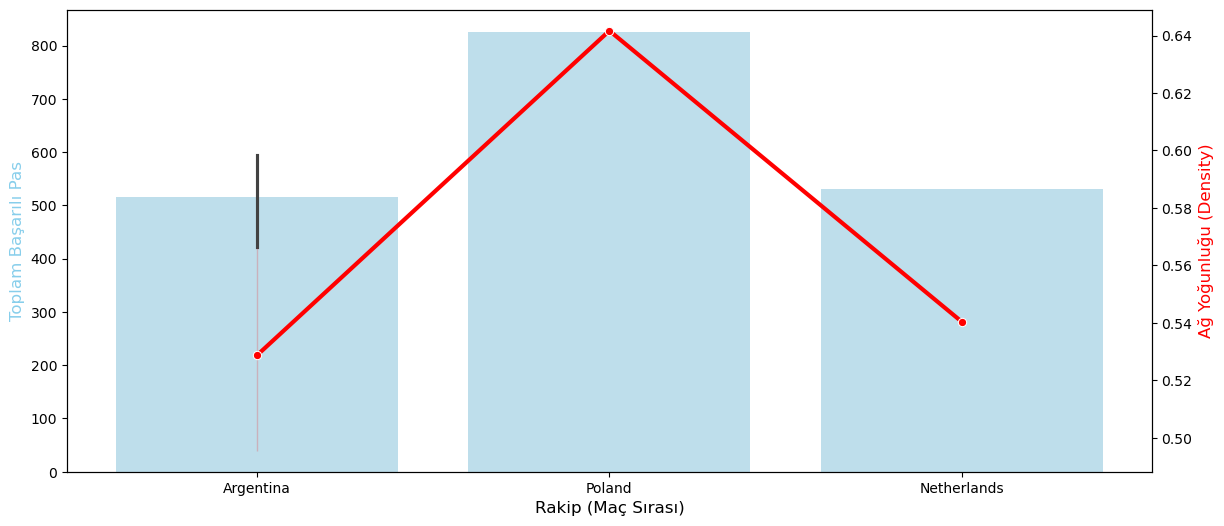

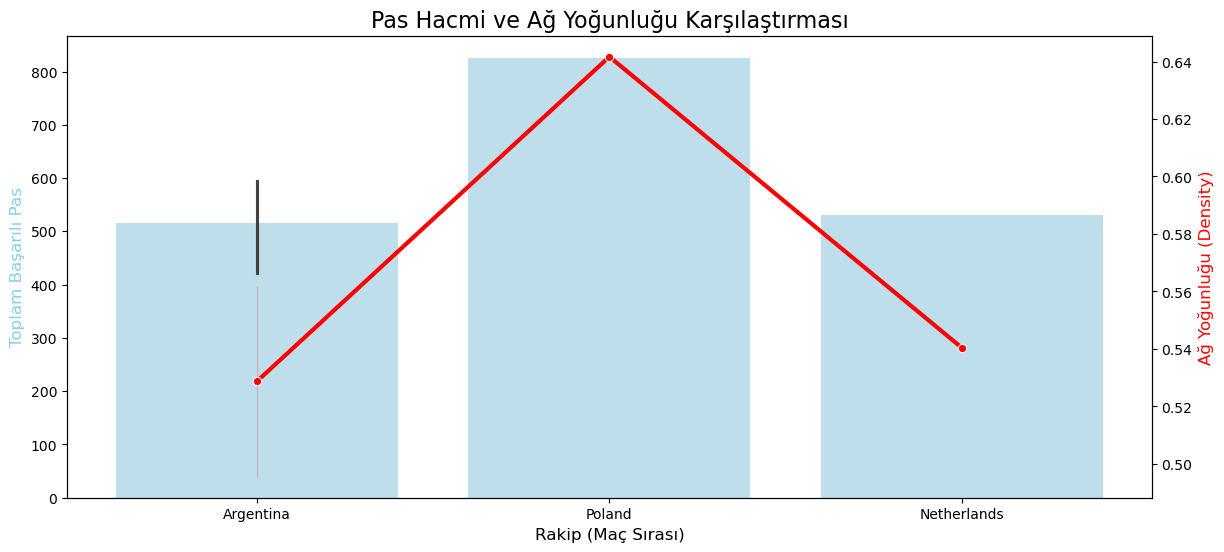

In [23]:
plt.figure(figsize=(14, 6))

# Çift eksenli grafik
ax1 = plt.gca()
ax2 = ax1.twinx()

sns.barplot(data=results_df, x='Opponent', y='Total Successful Passes', ax=ax1, color='skyblue', alpha=0.6)
sns.lineplot(data=results_df, x='Opponent', y='Network Density', ax=ax2, color='red', marker='o', linewidth=3, sort=False)

ax1.set_ylabel('Toplam Başarılı Pas', color='skyblue', fontsize=12)
ax2.set_ylabel('Ağ Yoğunluğu (Density)', color='red', fontsize=12)
ax1.set_xlabel('Rakip (Maç Sırası)', fontsize=12)
plt.title('Pas Hacmi ve Ağ Yoğunluğu Karşılaştırması', fontsize=16)
plt.show()

### B. Maçın Kilit Oyuncusu (Playmaker) Kimdi?
Her maçta **Betweenness Centrality** (Köprü kurma) değeri en yüksek olan oyuncu kimdi? Strateji maçtan maça değişti mi?

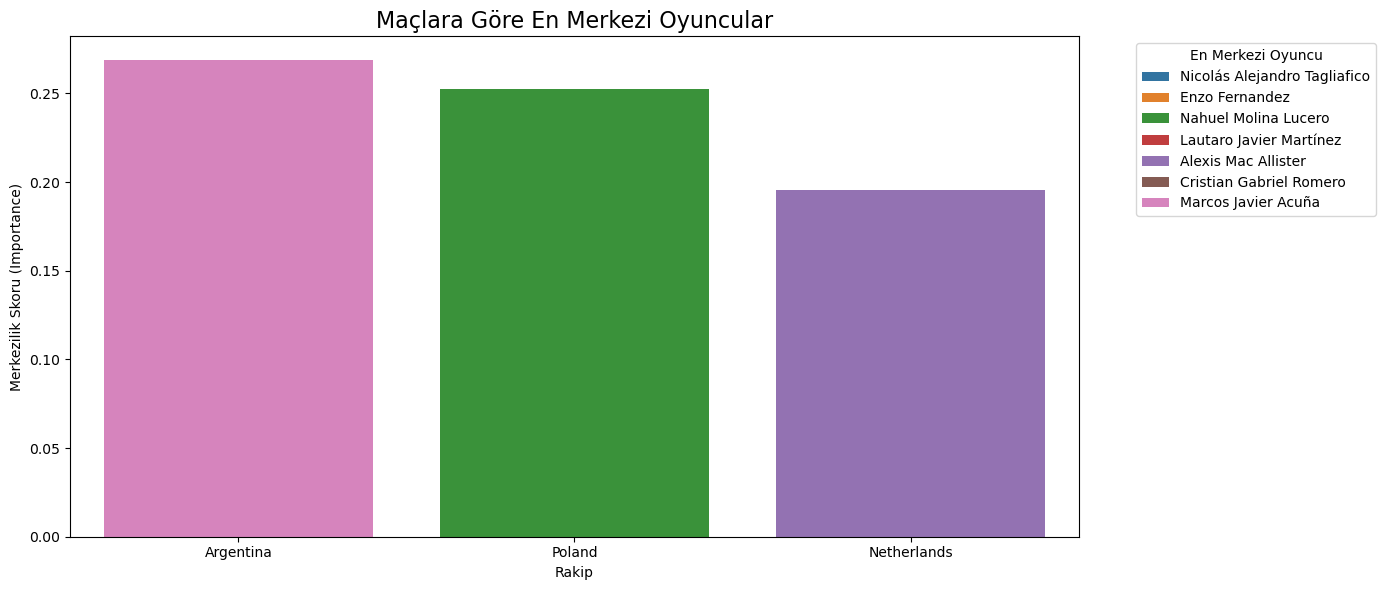

In [25]:
plt.figure(figsize=(14, 6))
sns.barplot(data=results_df, x='Opponent', y='Playmaker Score', hue='Key Playmaker', dodge=False)
plt.title('Maçlara Göre En Merkezi Oyuncular', fontsize=16)
plt.ylabel('Merkezilik Skoru (Importance)')
plt.xlabel('Rakip')
plt.legend(title='En Merkezi Oyuncu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()